■ Google drive **마운트**

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
!ls /content/drive/MyDrive/colab_backup/runs/detect/train_corrected # 마운트 잘 됐는지 확인

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2760.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2761.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch2762.jpg  weights
labels.jpg			 train_batch2.jpg


■ YOLO 패키지 설치
- ultralytics 패키지
- opencv-python 패키지

검증파일(test) 확인을 위한 패키지 설치

In [51]:
!pip install ultralytics opencv-python

In [41]:
!ls /content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/best.pt

/content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/best.pt


■ 학습결과 검증하기
- conf =0.25 -> 임계치

test 파일 내부 images로 검증해봄

In [46]:
# YOLOv8 예측 명령
!yolo detect predict \
    model=/content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/best.pt \
    source=/content/drive/MyDrive/colab_backup/data/test/images \
    conf=0.25 \
    save=True

Ultralytics 8.4.13 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs

image 1/111 /content/drive/MyDrive/colab_backup/data/test/images/VID20210601143927-96_jpg.rf.51037a593015ac38c8ac31613da3c066.jpg: 640x384 1 Cap1, 1 Cap2, 1 Cap3, 1 Cap4, 1 MOSFET, 1 Mov, 1 Resistor, 2 Transformers, 314.2ms
image 2/111 /content/drive/MyDrive/colab_backup/data/test/images/VID20210601143927-96_jpg.rf.7ab5347b2d9efca349318d1c0f12a466.jpg: 640x384 1 Cap1, 1 Cap2, 1 Cap3, 1 Cap4, 1 MOSFET, 1 Mov, 1 Resistor, 2 Transformers, 551.1ms
image 3/111 /content/drive/MyDrive/colab_backup/data/test/images/VID20210601143927-96_jpg.rf.f5f54e1ed4ec2434ed16cb072a95de94.jpg: 640x384 1 Cap1, 1 Cap2, 1 Cap3, 1 Cap4, 1 MOSFET, 1 Mov, 1 Resistor, 2 Transformers, 156.9ms
image 4/111 /content/drive/MyDrive/colab_backup/data/test/images/VID20210601144014-45_jpg.rf.3f10bd61f03a52d57d80d50bffa68cb7.jpg: 640x384 1 Cap1, 1 Cap2, 1 Cap3, 1

■ 검증한 학습결과 시각화

- conf =0.25 -> 임계치

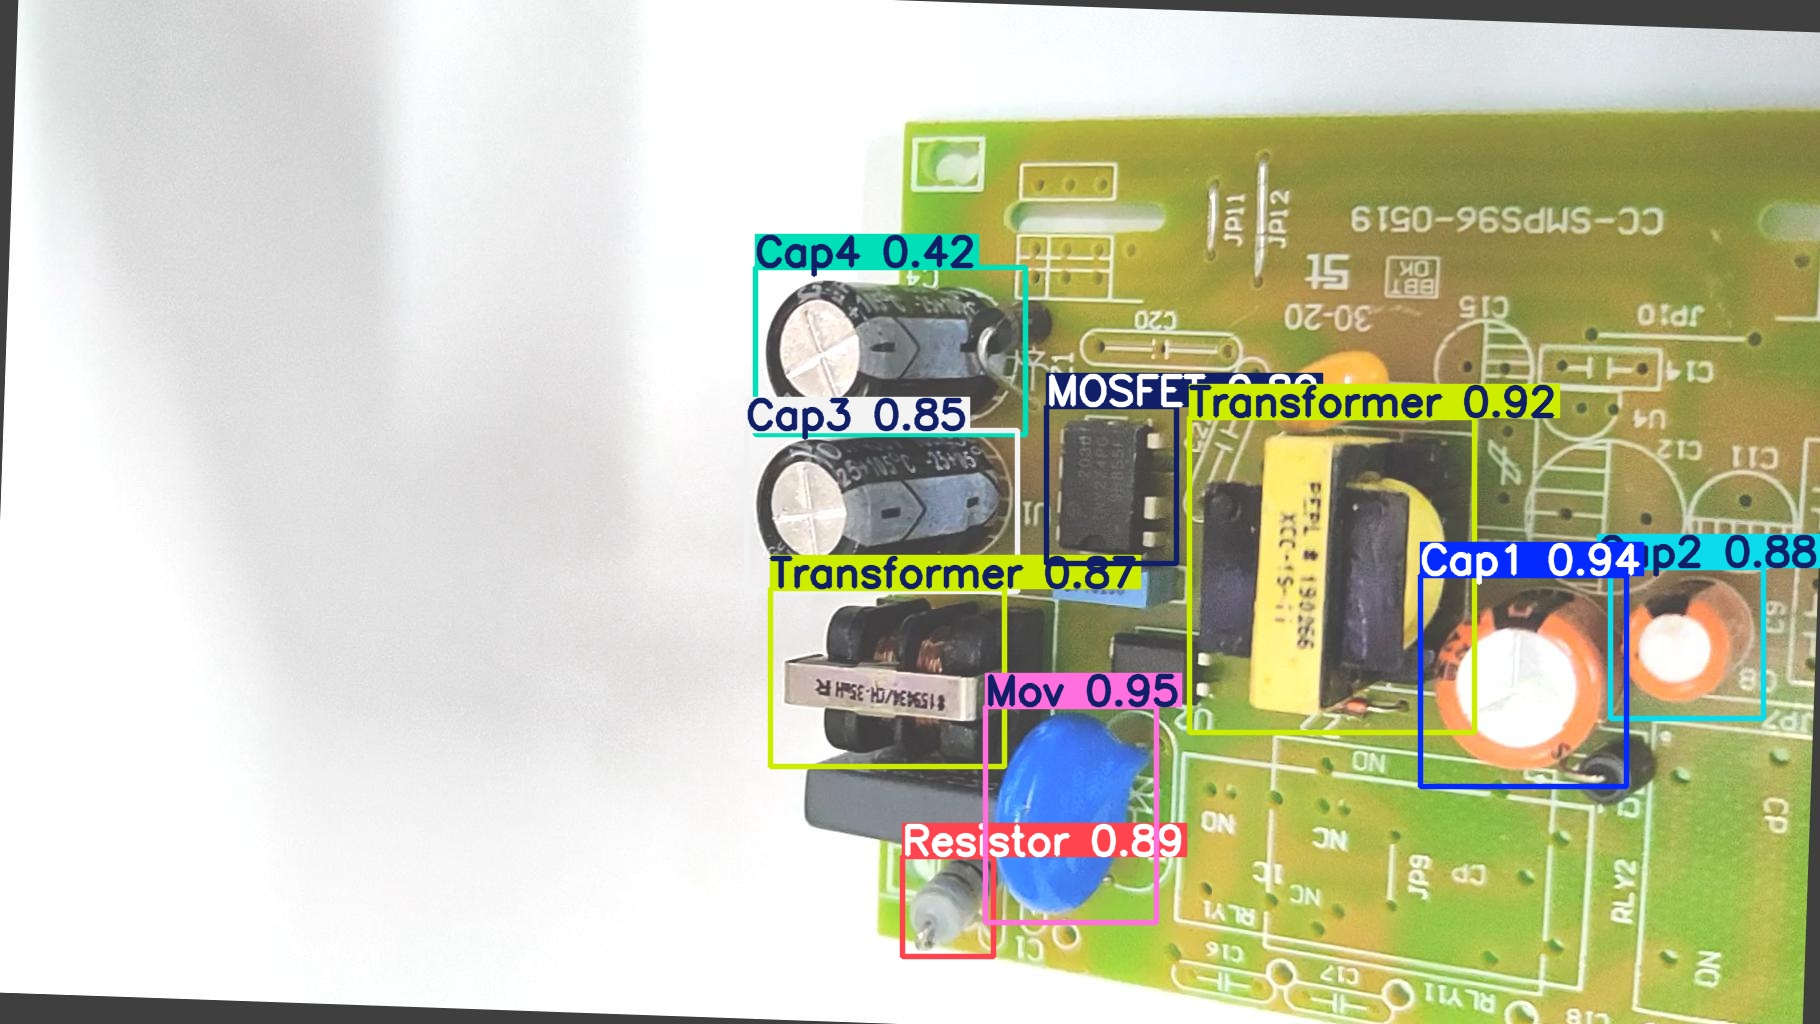

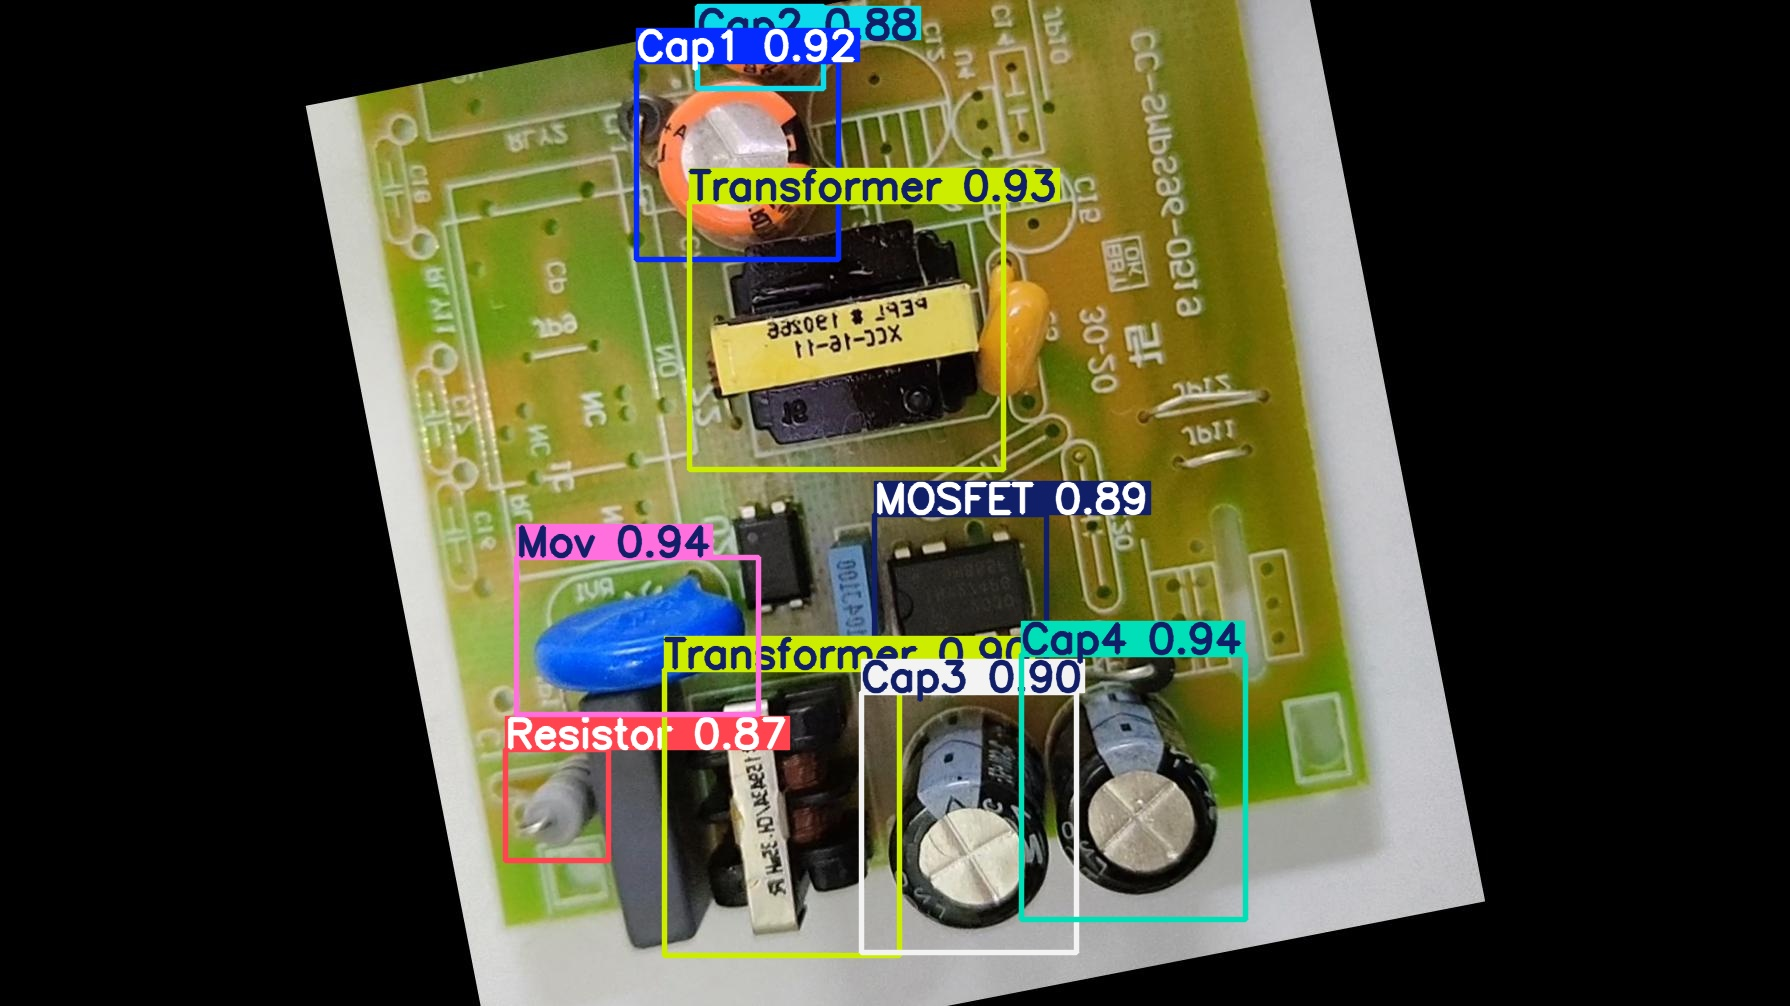

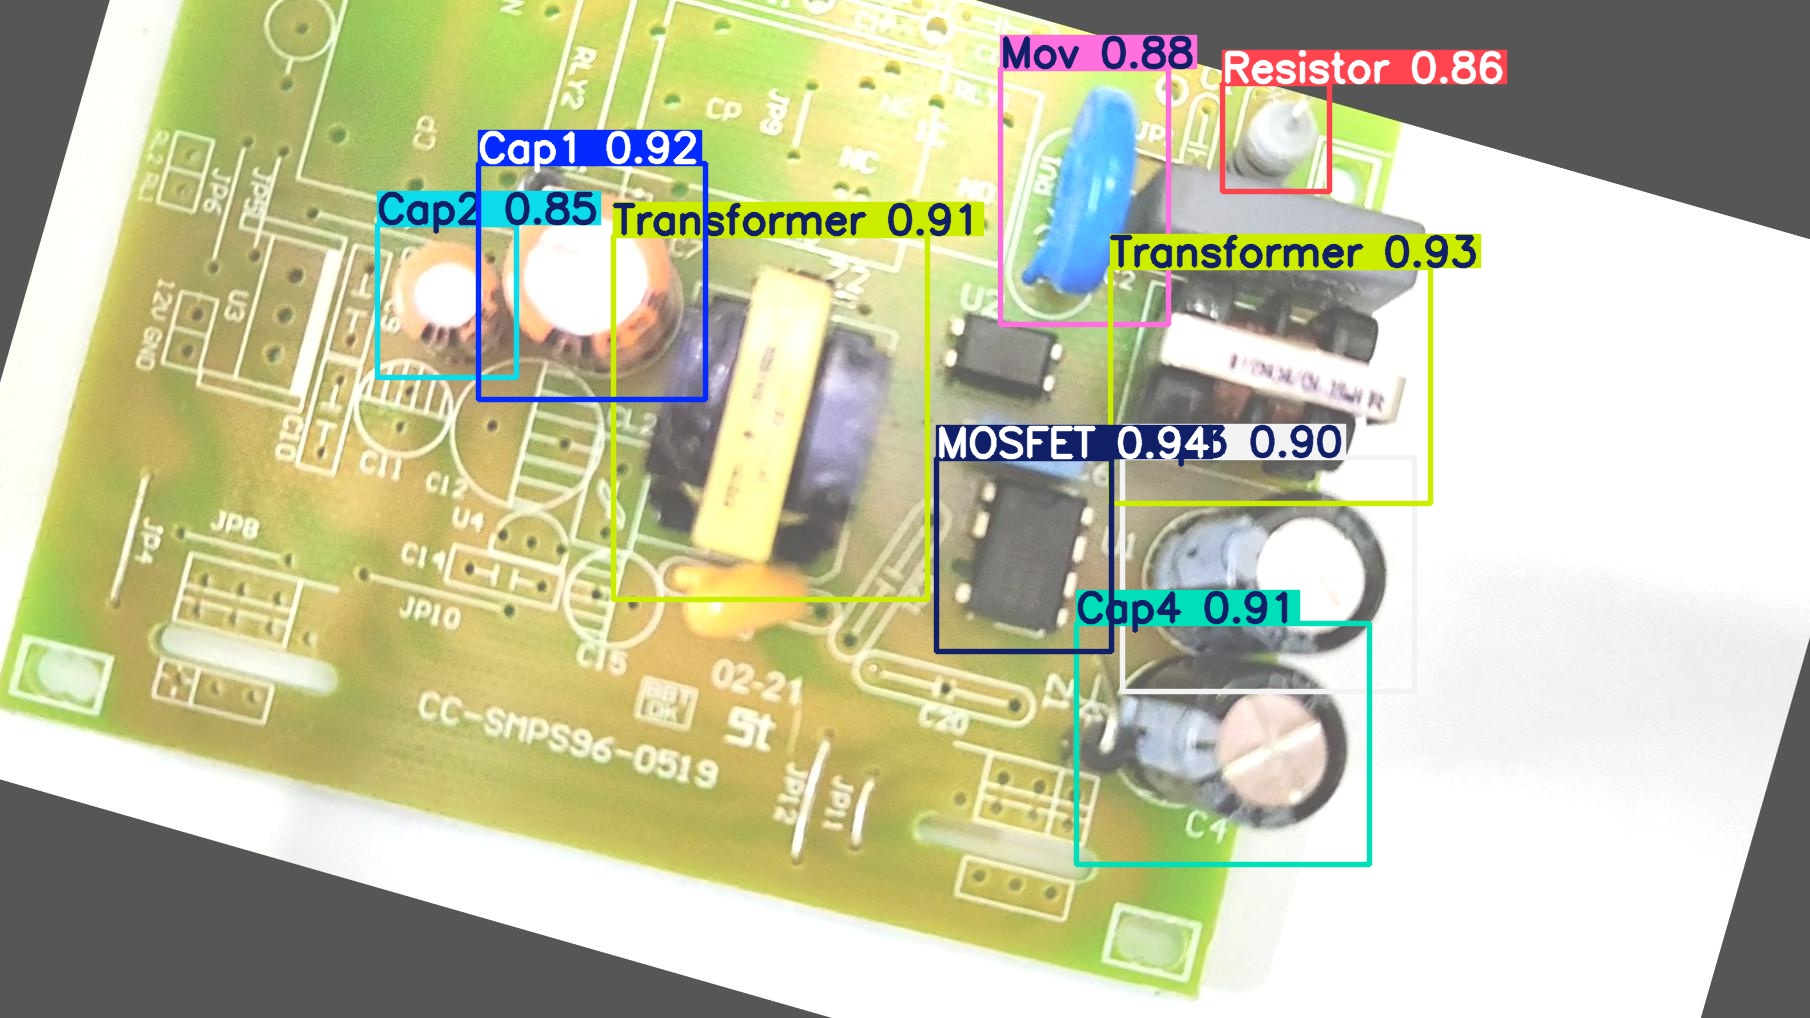

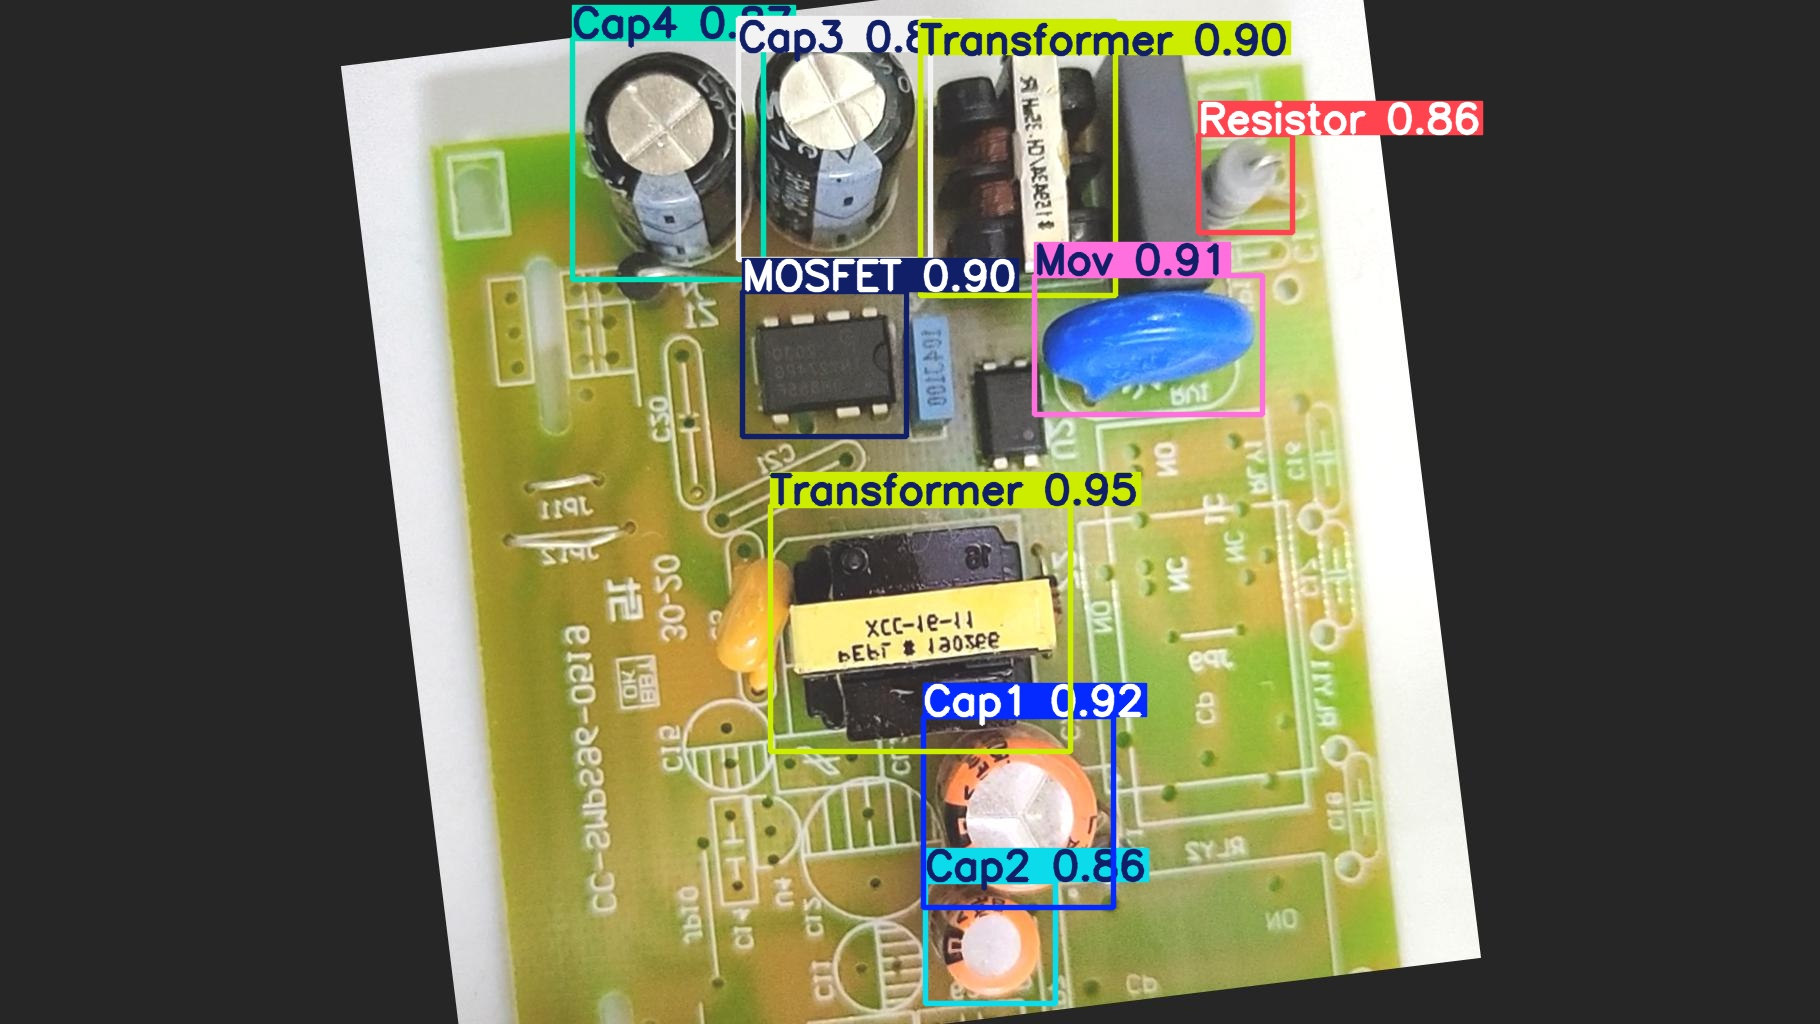

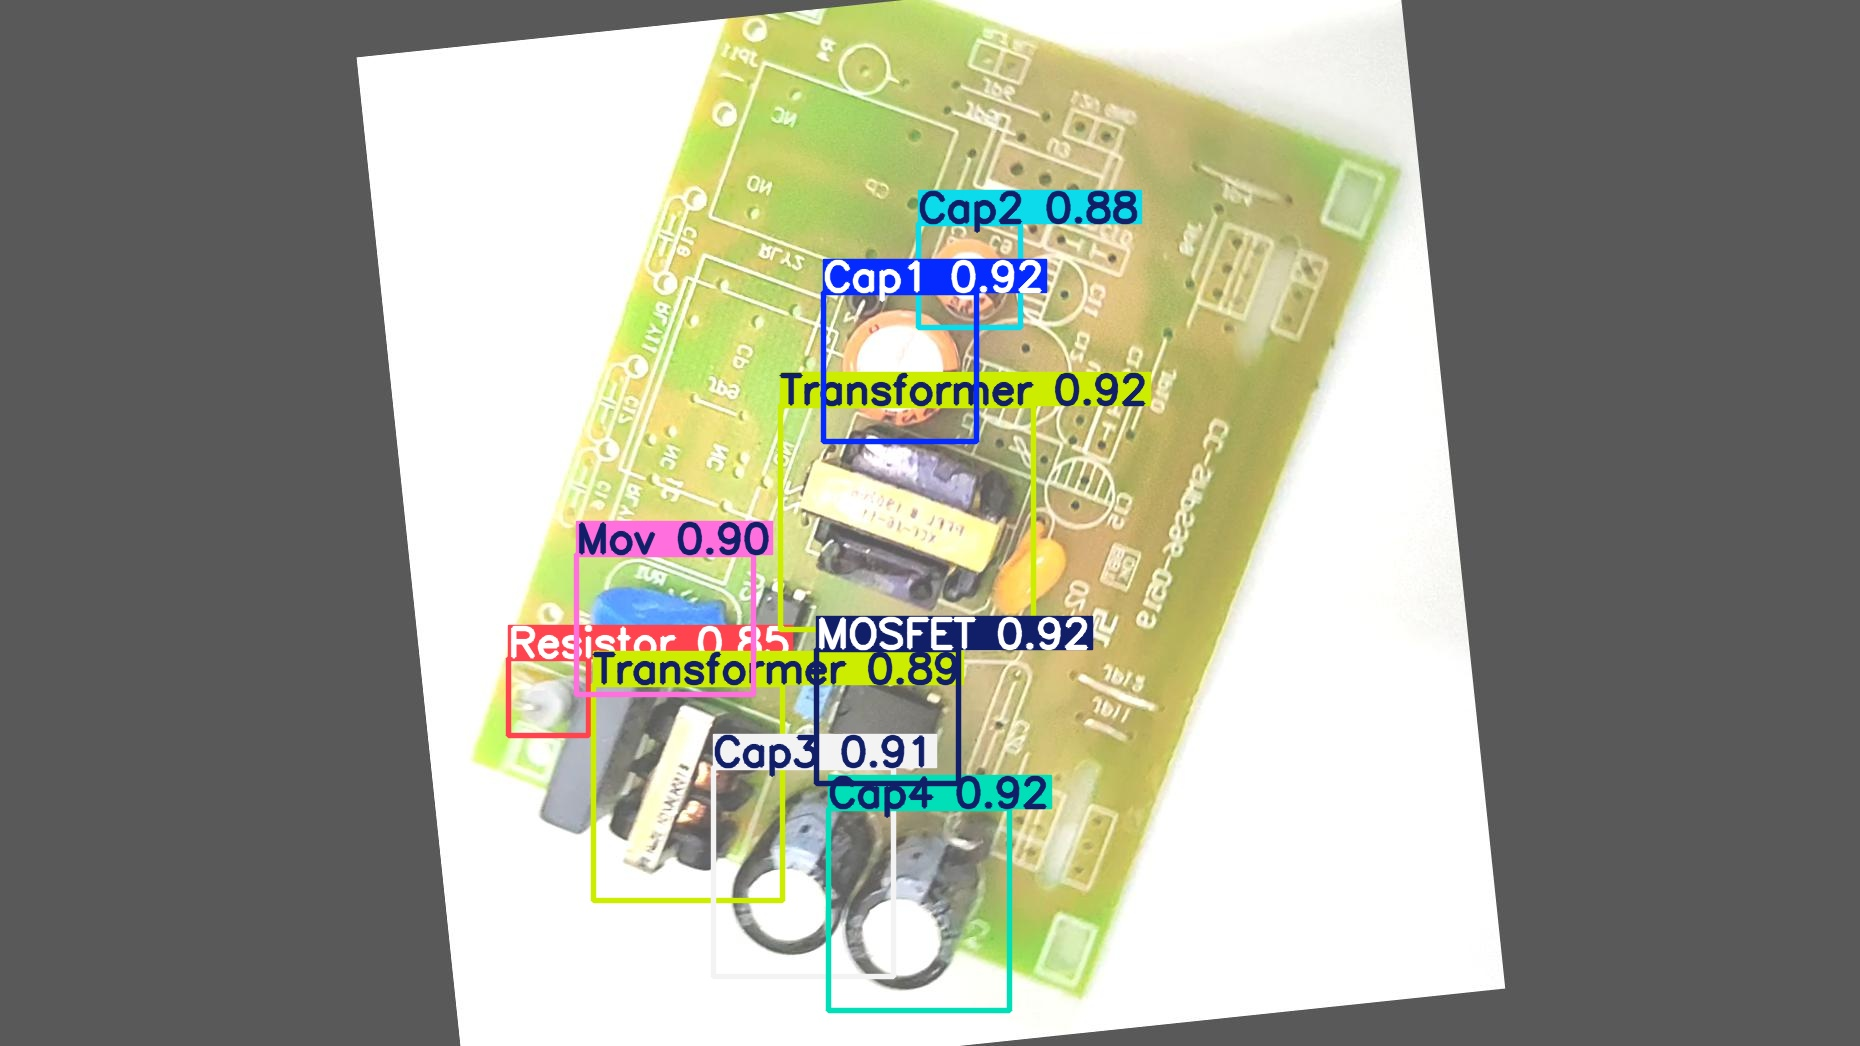

In [47]:
import os
from IPython.display import Image, display

# 1. 예측 결과 폴더
predict_dir = "runs/detect/predict"

# 2. 폴더 안 이미지 파일 목록 가져오기
img_files = [f for f in os.listdir(predict_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# 3. 상위 5개 이미지 선택
img_files = img_files[:5]

# 4. 이미지 표시
for img_file in img_files:
    display(Image(filename=os.path.join(predict_dir, img_file)))


■ 검증결과 Goolge drive에 마운트

In [48]:
import shutil

shutil.copytree(
    '/content/runs/detect/predict', # 생성된 학습결과 경로
    '/content/drive/MyDrive/colab_backup/runs/detect/predict'#Google drive에 마운트한 학습결과 경로
)

'/content/drive/MyDrive/colab_backup/runs/detect/predict'

■ 학습성능 확인

Loss, mAP, Precision, Recall

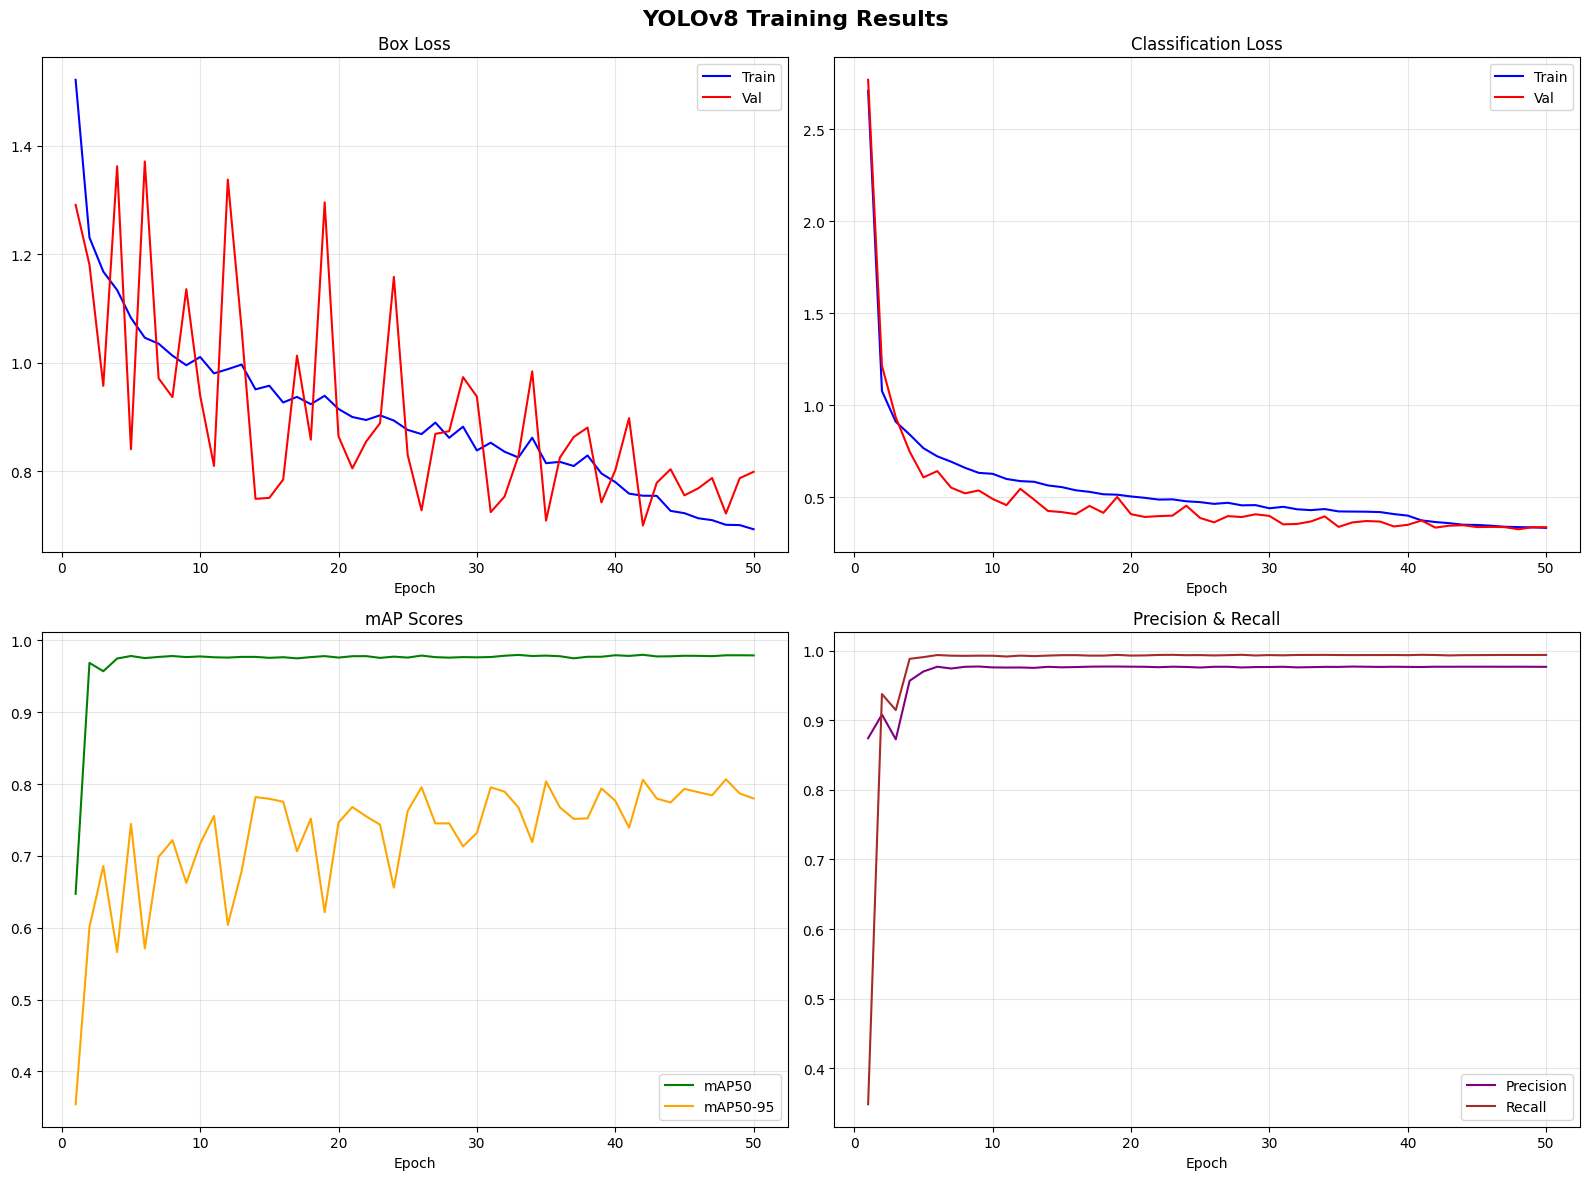


===== 최종 학습 성능 (Epoch 50) =====
  mAP50:      0.9791
  mAP50-95:   0.7799
  Precision:   0.9769
  Recall:      0.9941


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_dir = '/content/drive/MyDrive/colab_backup/runs/detect/train_corrected'

results = pd.read_csv(f'{train_dir}/results.csv')
results.columns = results.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0][0].plot(results['epoch'], results['train/box_loss'], label='Train', color='blue')
axes[0][0].plot(results['epoch'], results['val/box_loss'], label='Val', color='red')
axes[0][0].set_title('Box Loss')
axes[0][0].set_xlabel('Epoch')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

axes[0][1].plot(results['epoch'], results['train/cls_loss'], label='Train', color='blue')
axes[0][1].plot(results['epoch'], results['val/cls_loss'], label='Val', color='red')
axes[0][1].set_title('Classification Loss')
axes[0][1].set_xlabel('Epoch')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

axes[1][0].plot(results['epoch'], results['metrics/mAP50(B)'], label='mAP50', color='green')
axes[1][0].plot(results['epoch'], results['metrics/mAP50-95(B)'], label='mAP50-95', color='orange')
axes[1][0].set_title('mAP Scores')
axes[1][0].set_xlabel('Epoch')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

axes[1][1].plot(results['epoch'], results['metrics/precision(B)'], label='Precision', color='purple')
axes[1][1].plot(results['epoch'], results['metrics/recall(B)'], label='Recall', color='brown')
axes[1][1].set_title('Precision & Recall')
axes[1][1].set_xlabel('Epoch')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.suptitle('YOLOv8 Training Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

last = results.iloc[-1]
print(f"\n===== 최종 학습 성능 (Epoch {int(last['epoch'])}) =====")
print(f"  mAP50:      {last['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95:   {last['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision:   {last['metrics/precision(B)']:.4f}")
print(f"  Recall:      {last['metrics/recall(B)']:.4f}")

■ 학습성능 확인

Loss, mAP, Precision, Recall


===== 혼동 행렬 =====


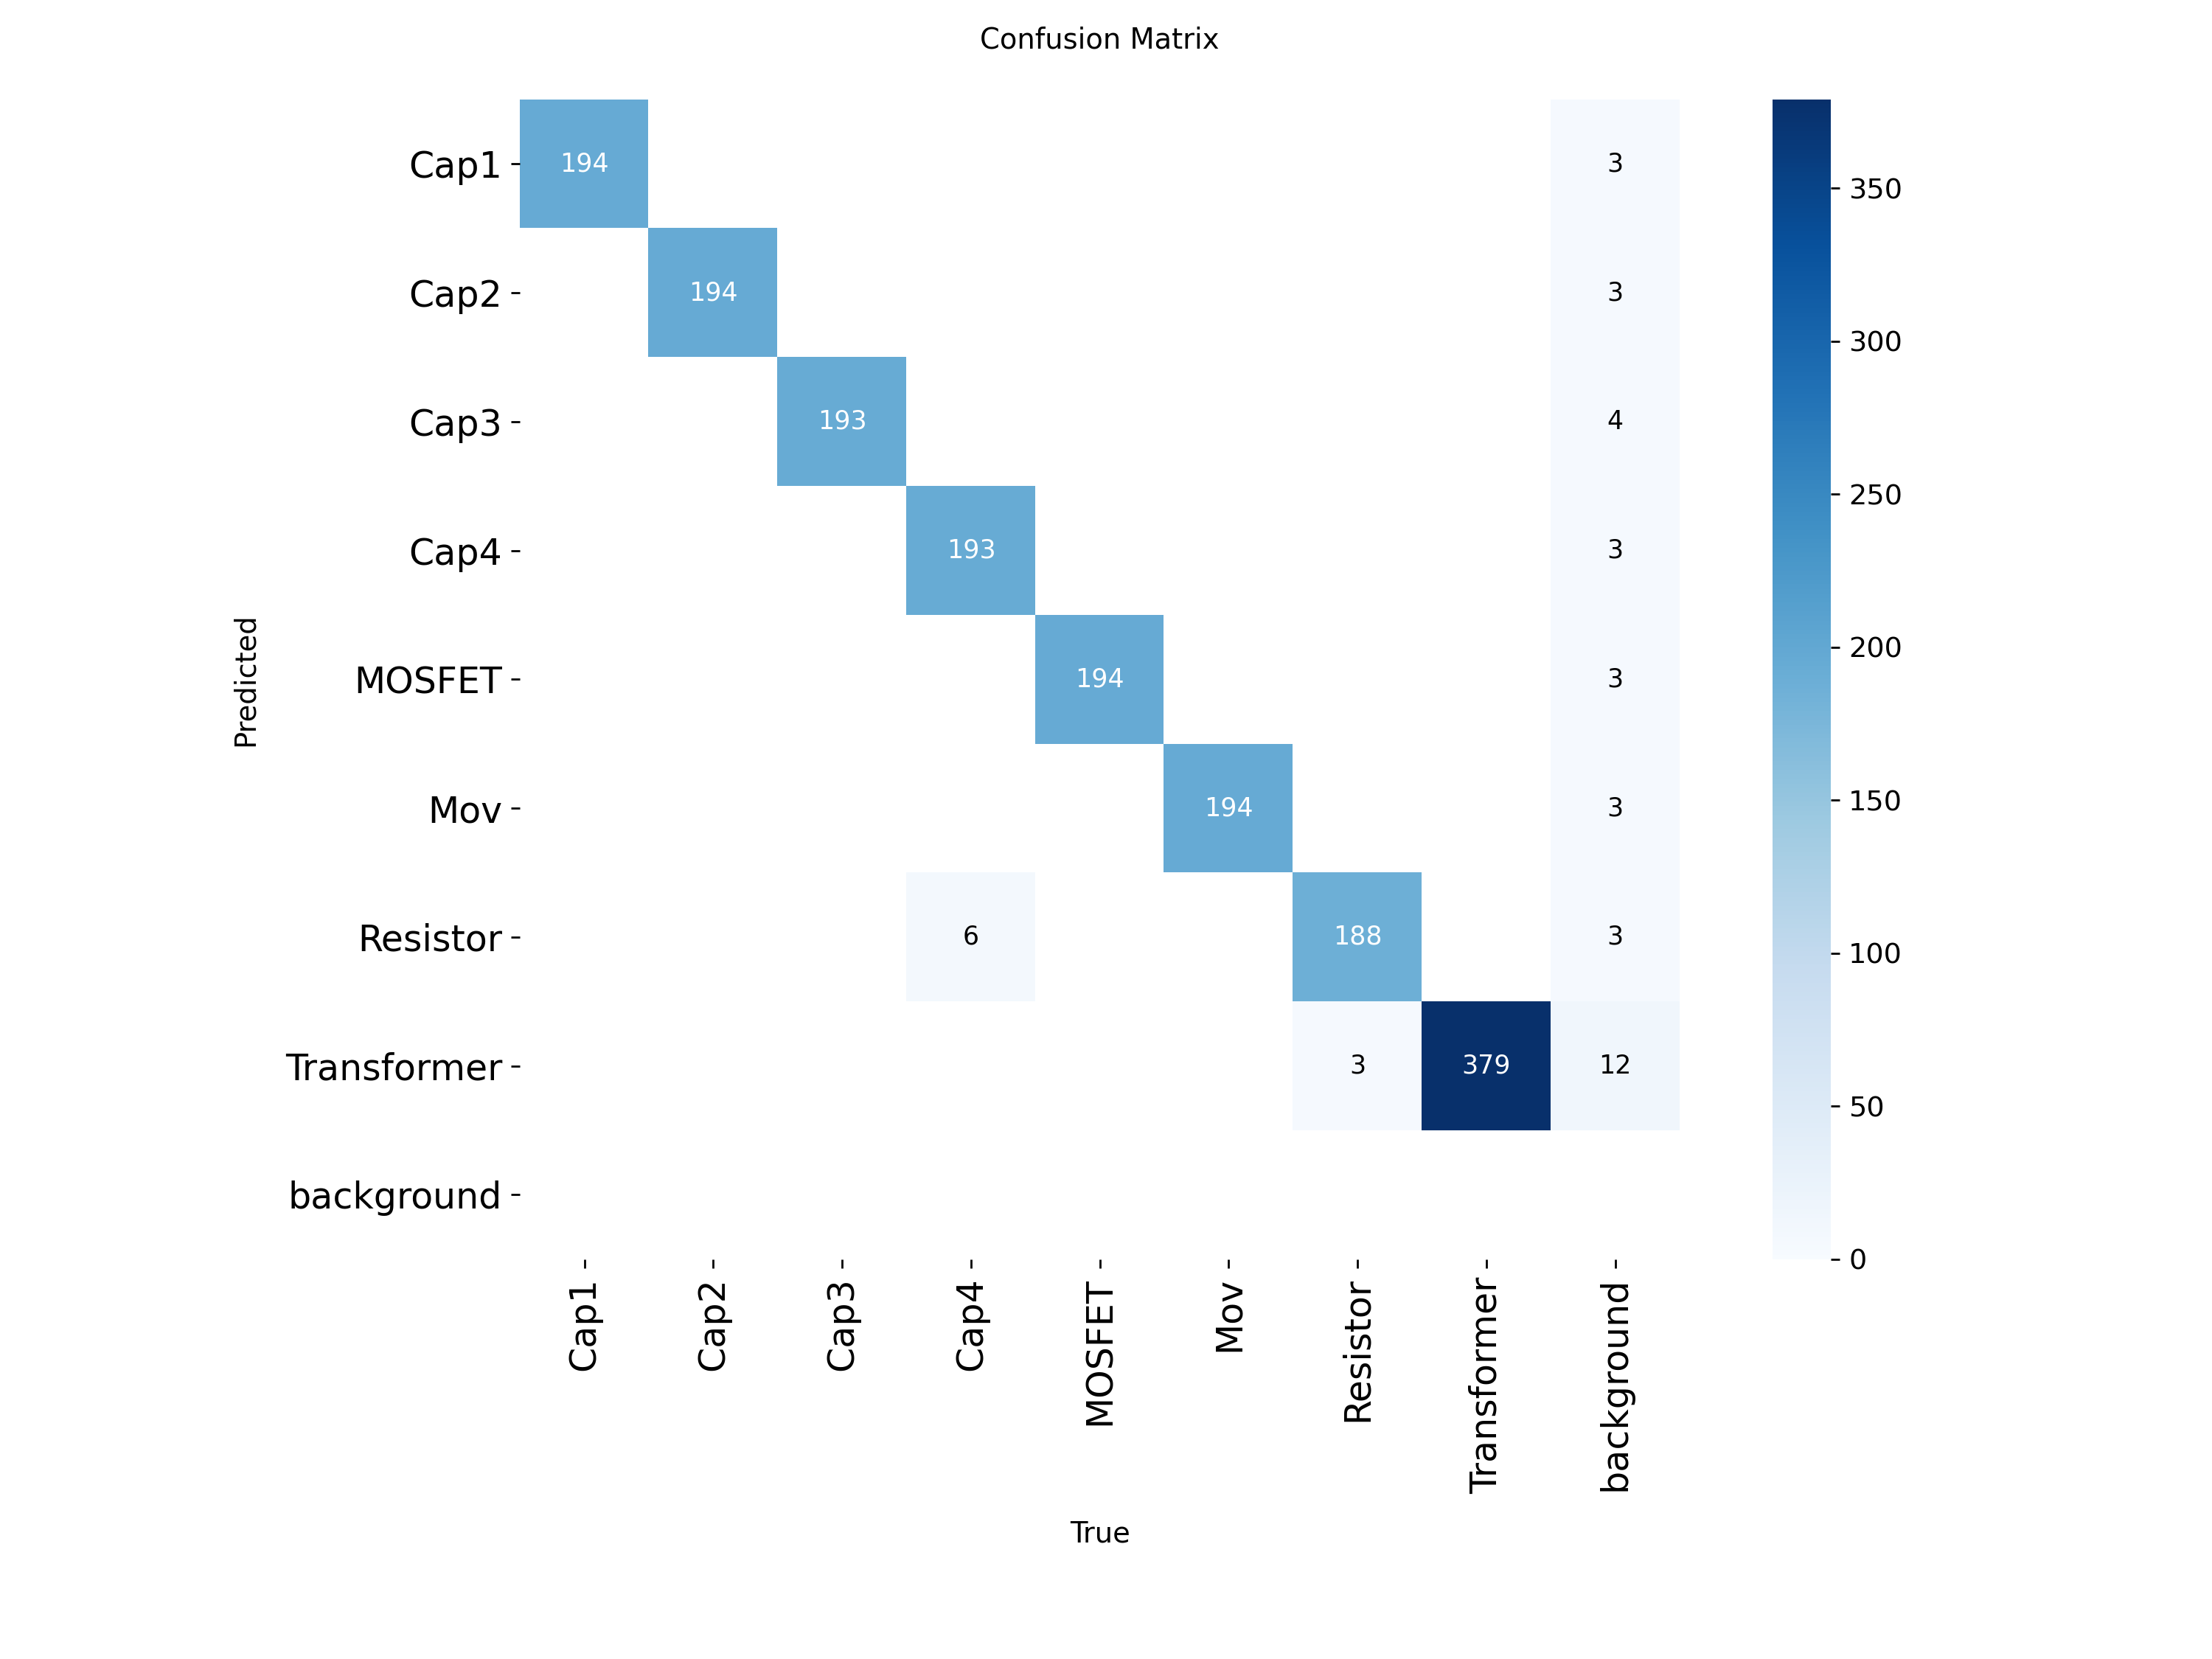


===== 혼동 행렬 (정규화) =====


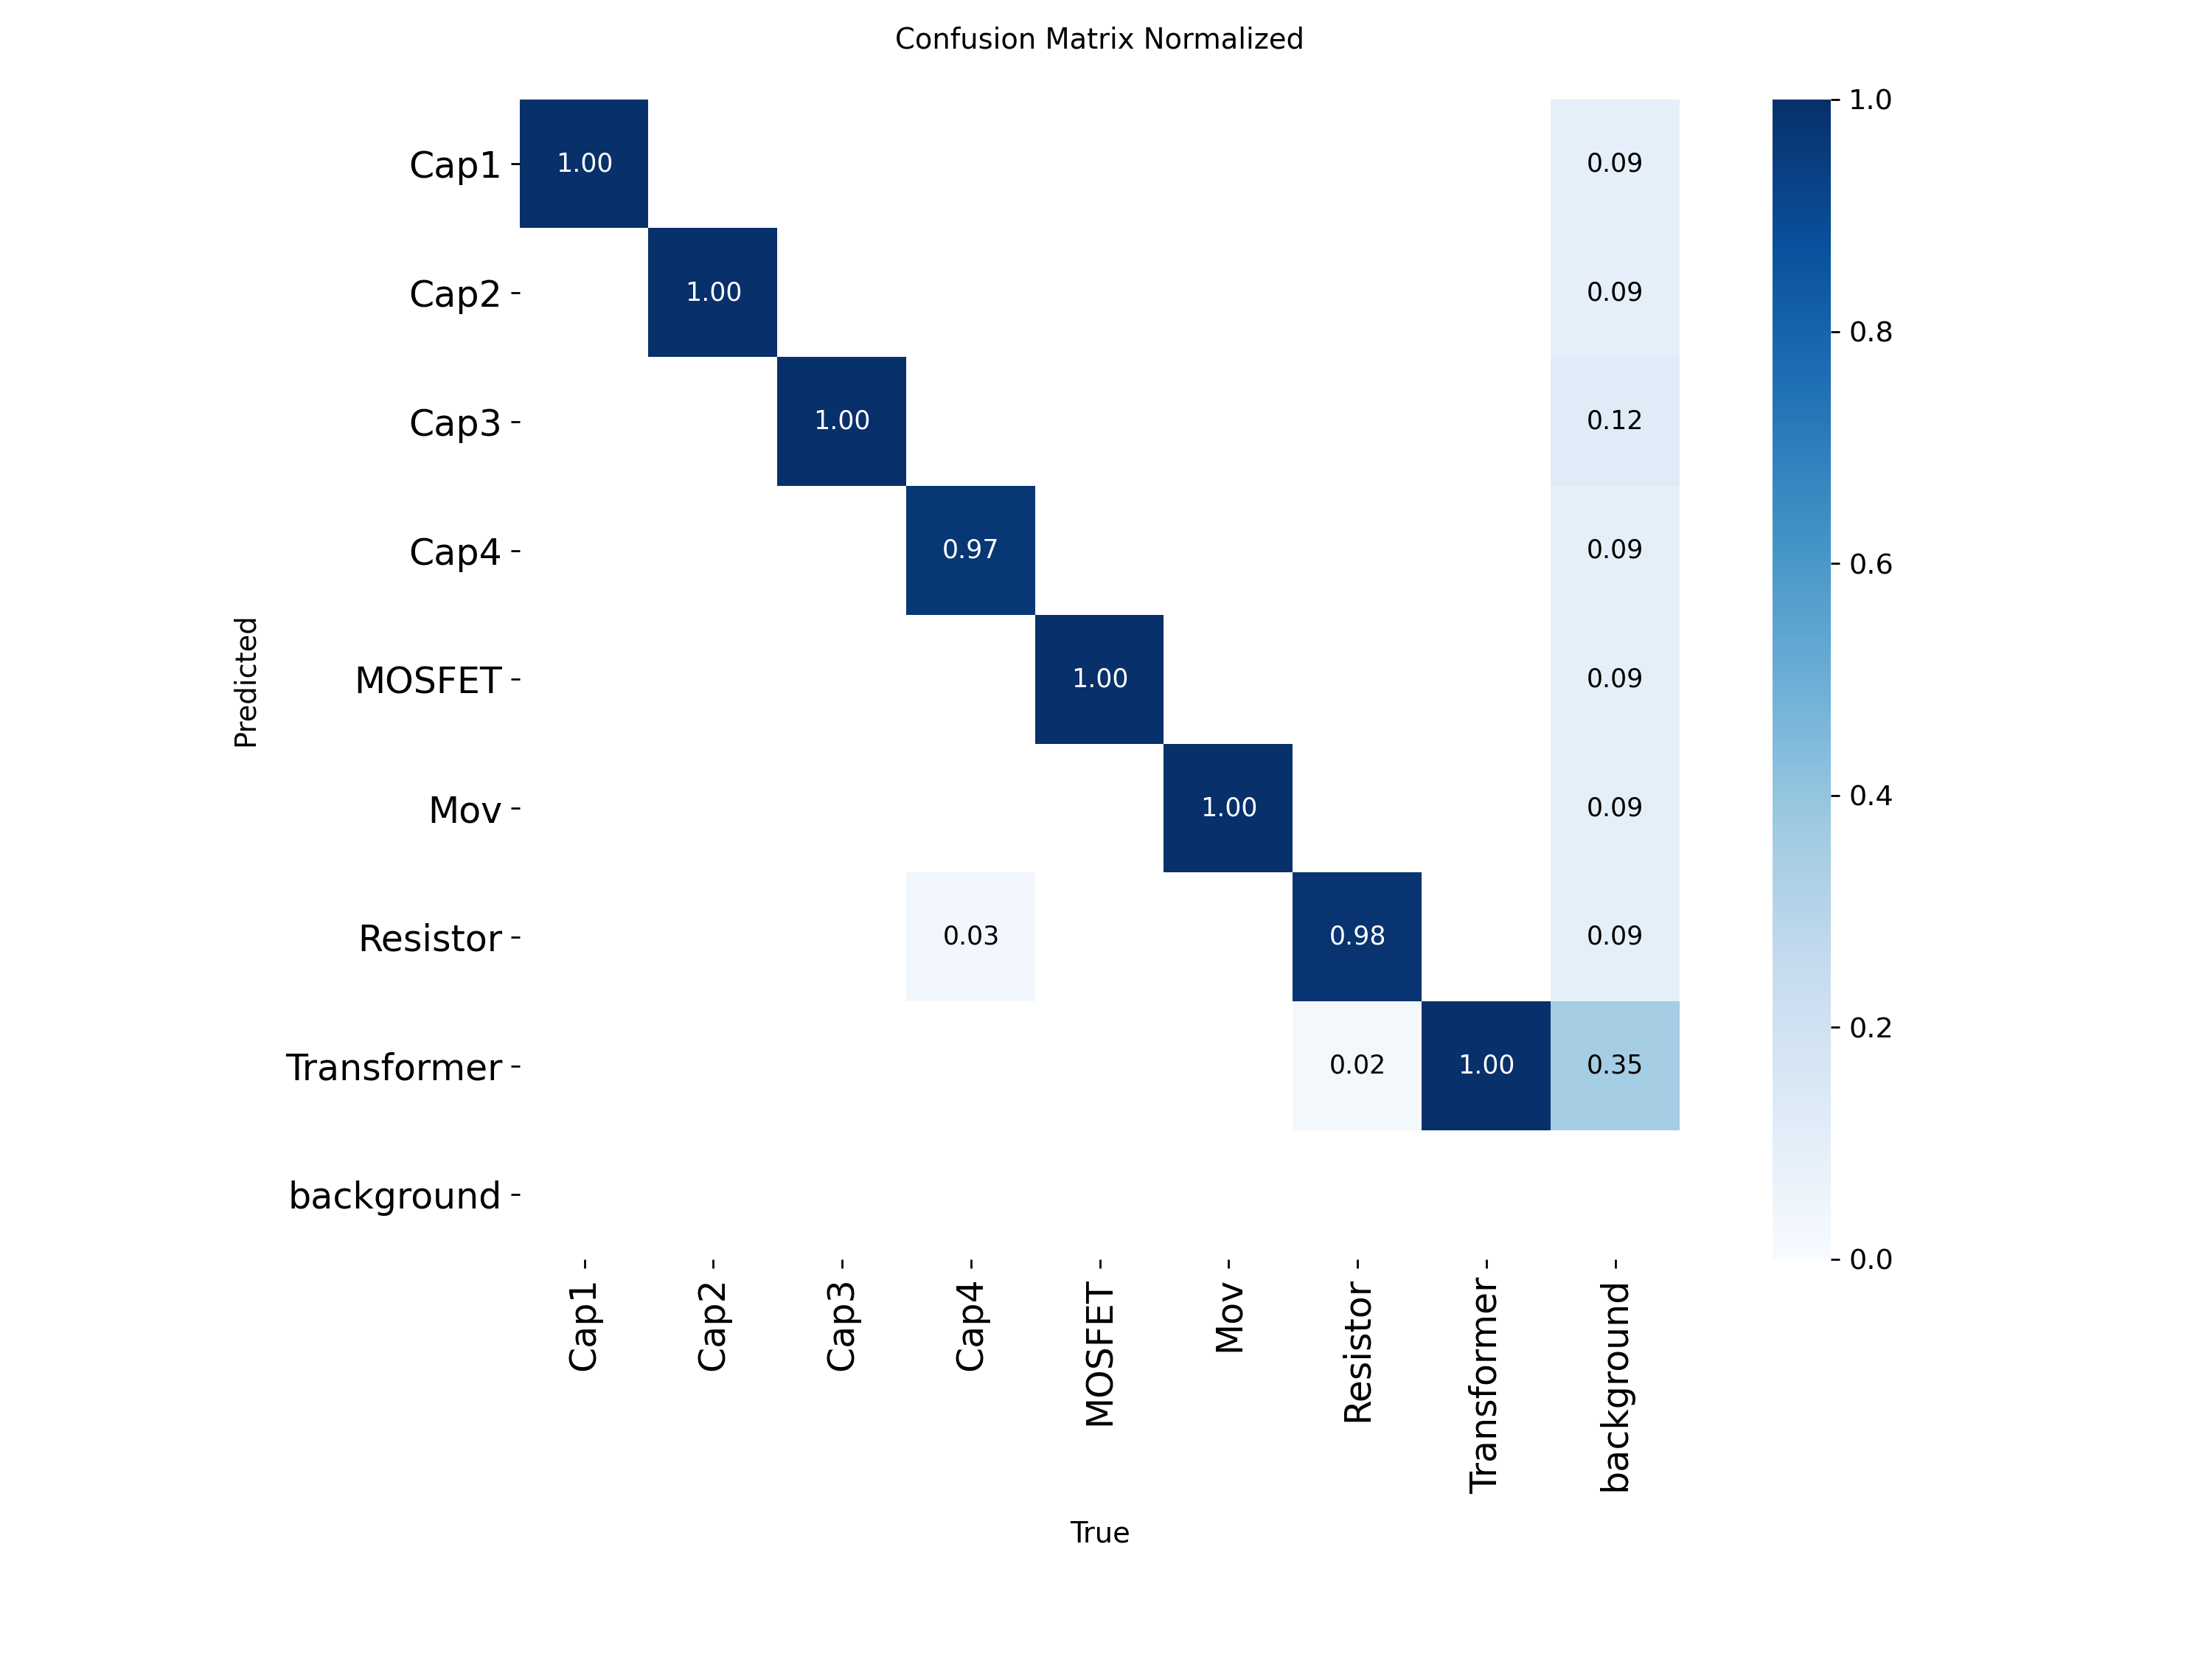


===== F1 Score 곡선 =====


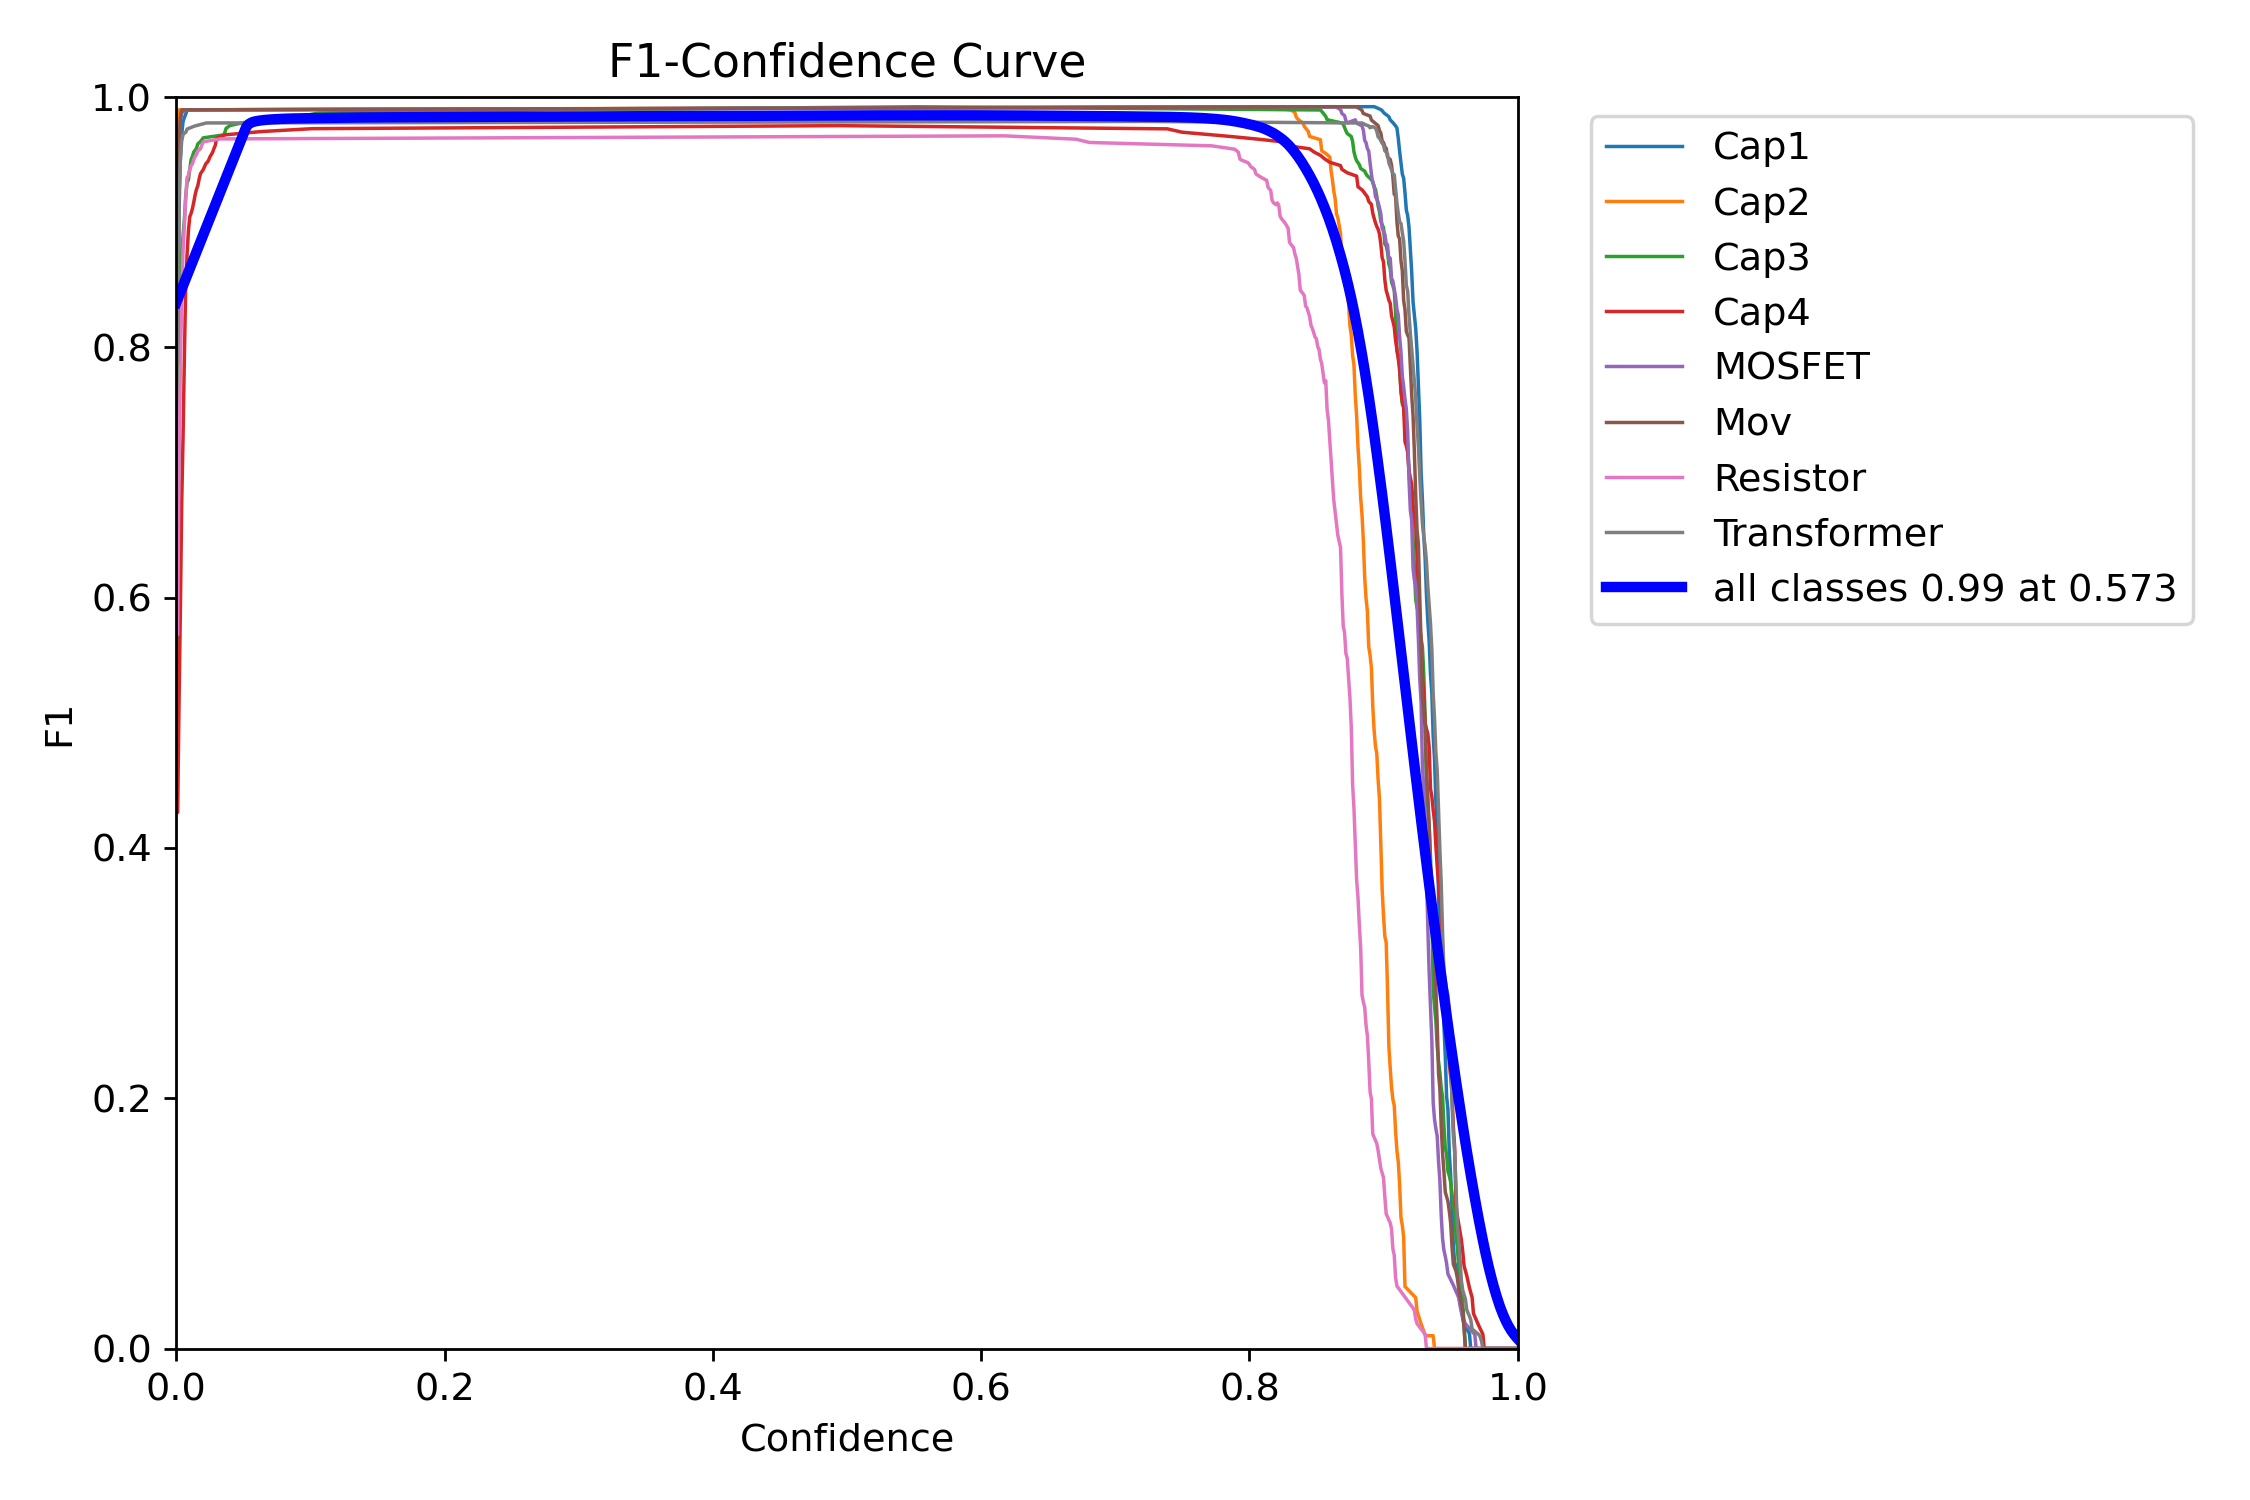


===== Precision-Recall 곡선 =====


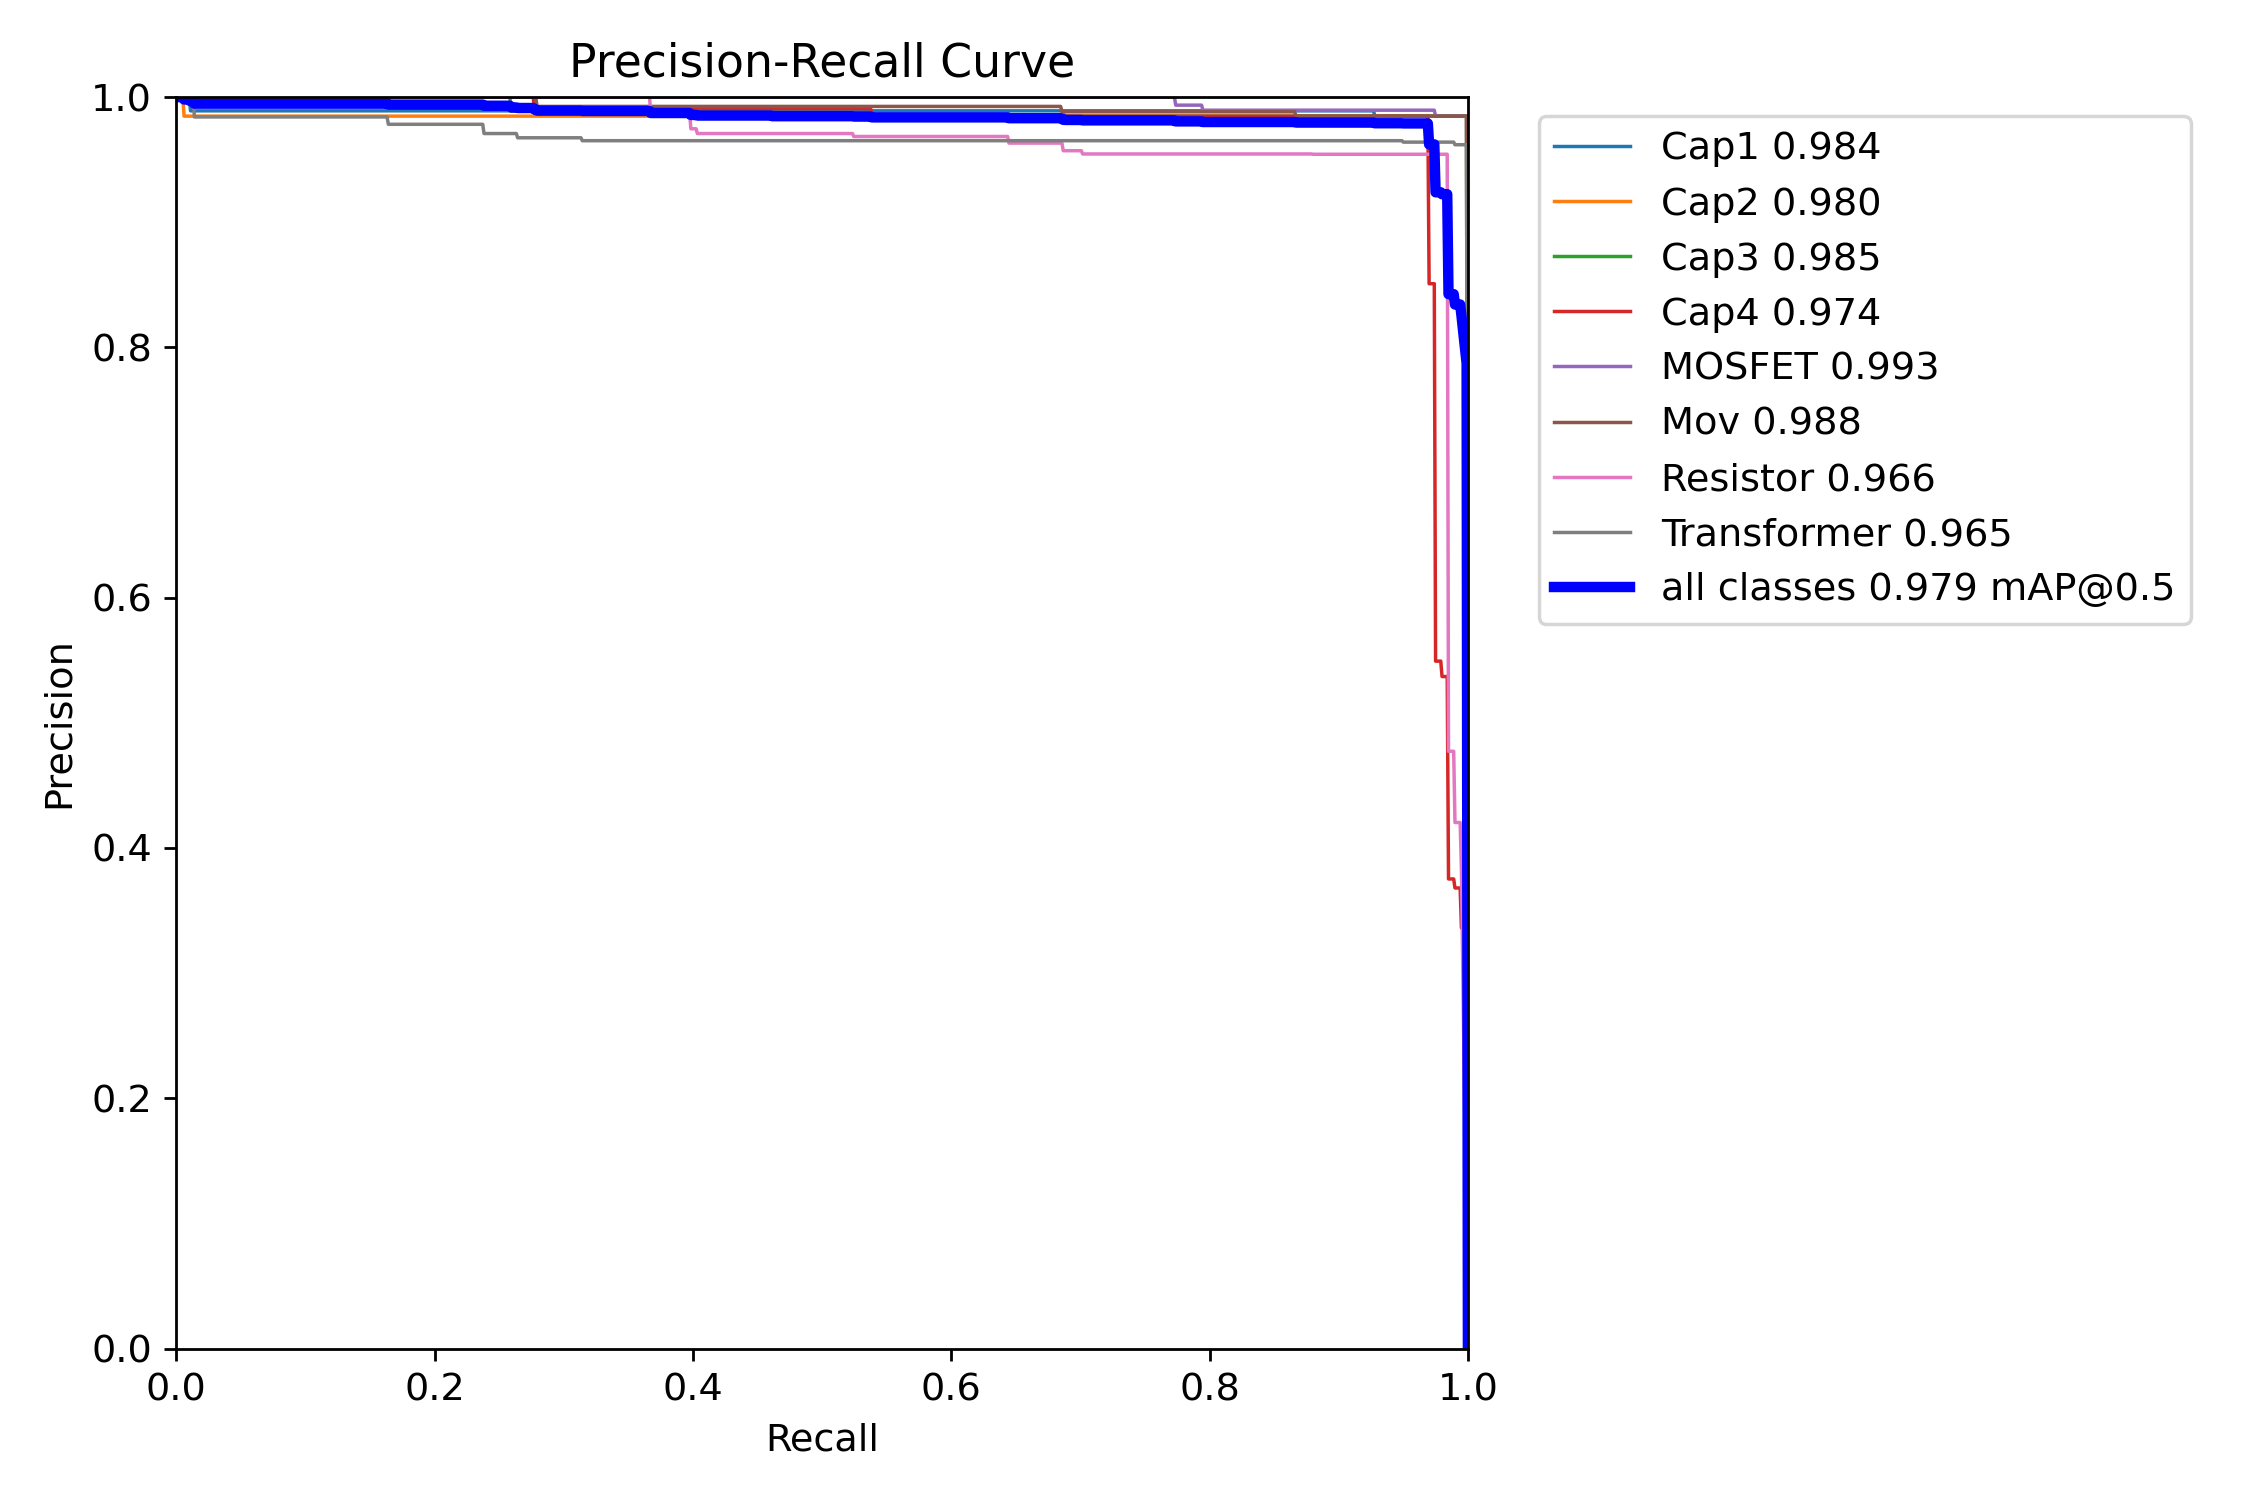


===== Precision 곡선 =====


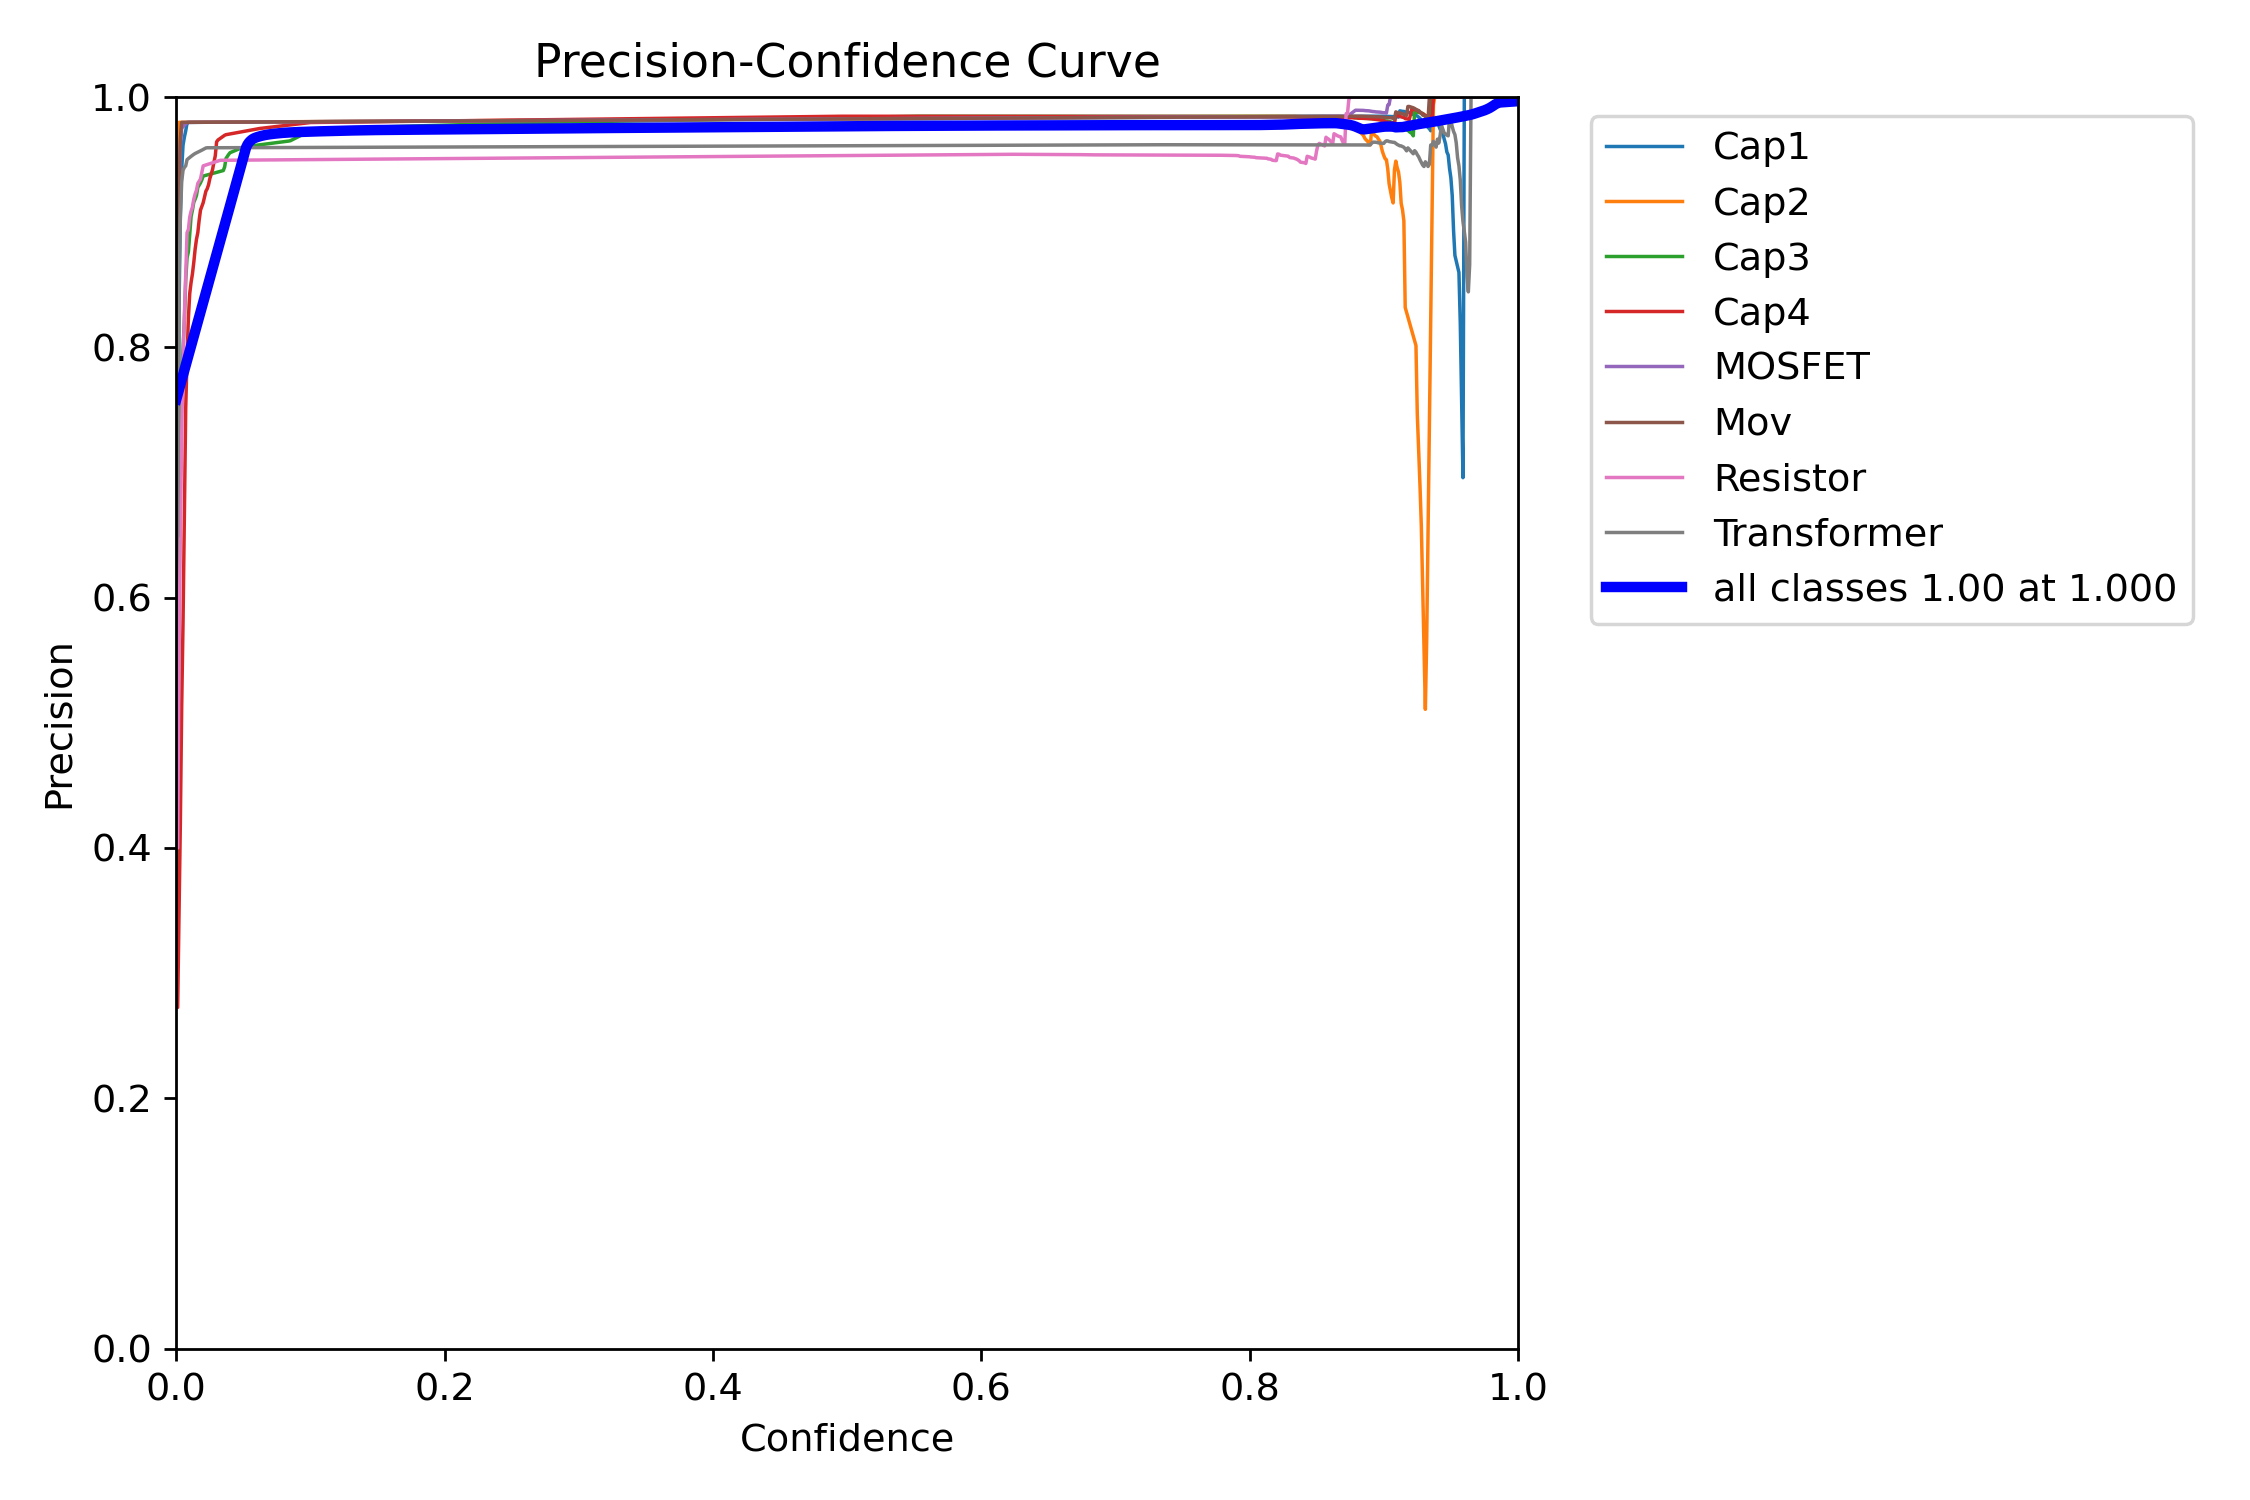


===== Recall 곡선 =====


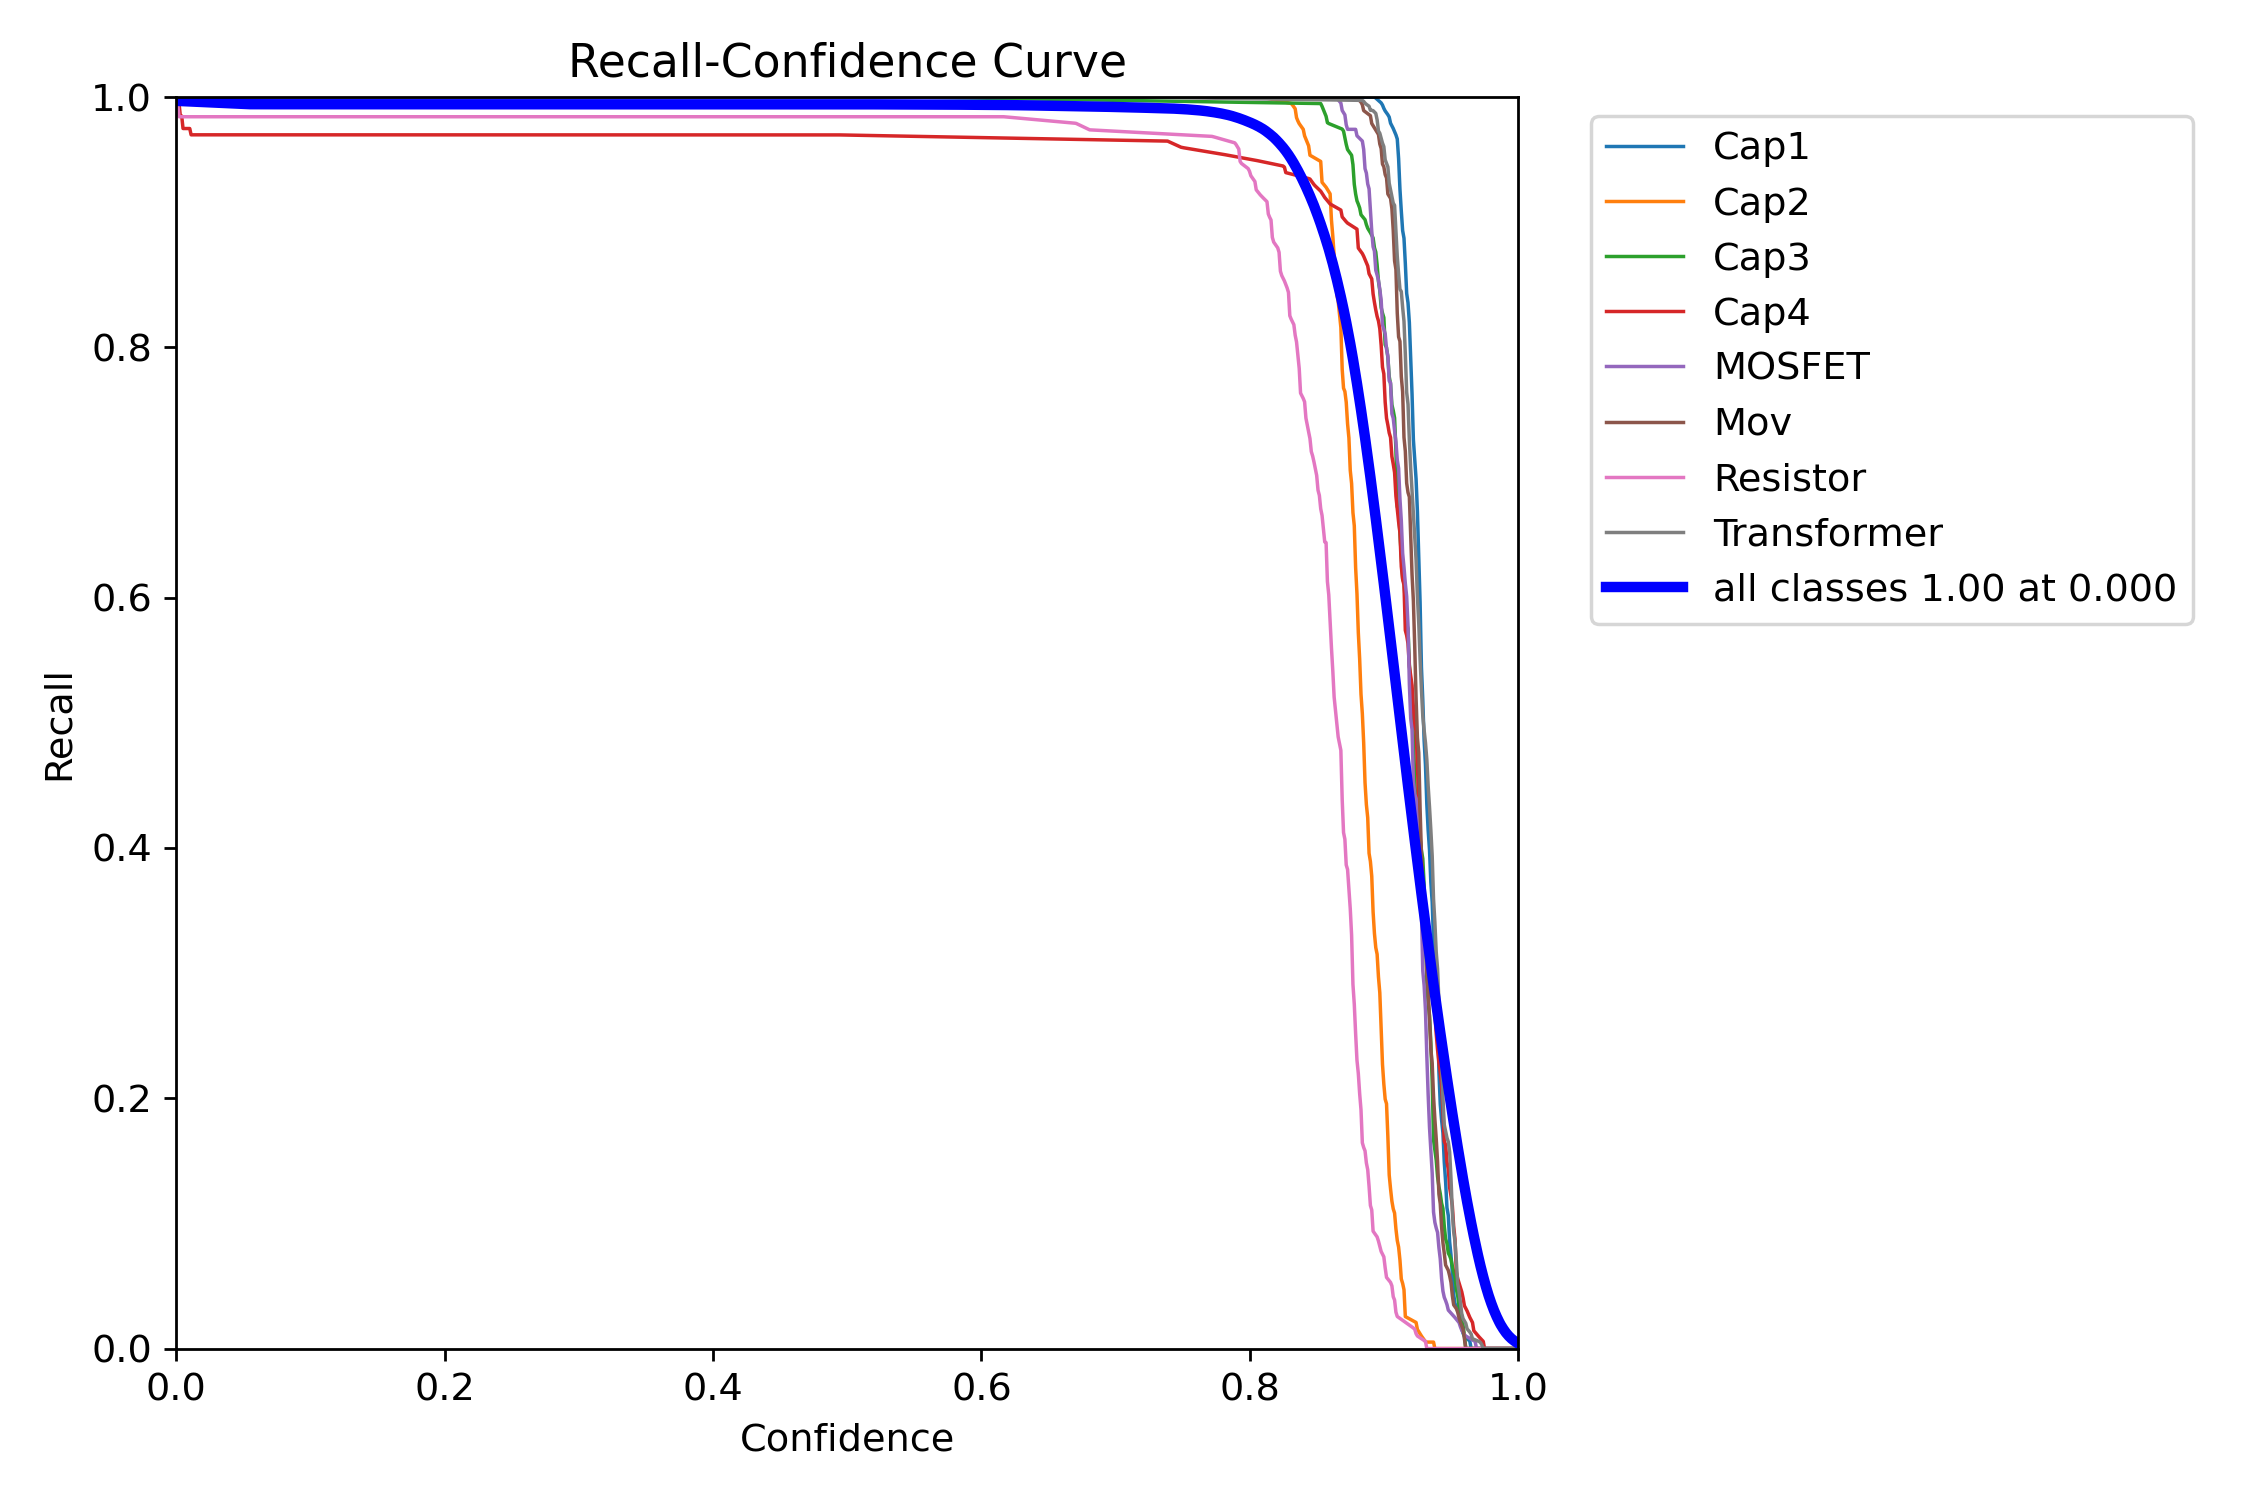

In [ ]:
from IPython.display import Image, display
import os

train_dir = '/content/drive/MyDrive/colab_backup/runs/detect/train_corrected'

image_files = {
    '혼동 행렬': 'confusion_matrix.png',
    '혼동 행렬 (정규화)': 'confusion_matrix_normalized.png',
    'F1 Score 곡선': 'BoxF1_curve.png',
    'Precision-Recall 곡선': 'BoxPR_curve.png',
    'Precision 곡선': 'BoxP_curve.png',
    'Recall 곡선': 'BoxR_curve.png',
}

for title, filename in image_files.items():
    filepath = os.path.join(train_dir, filename)
    if os.path.exists(filepath):
        print(f"\n===== {title} =====")
        display(Image(filename=filepath, width=700))
    else:
        print(f"\n===== {title} ===== ❌ 파일 없음: {filename}")